# 因子测试 · 03：Fusion Factor对中国波动率的预测能力分析

**核心问题**：当Fusion Factor出现较大正值（国家队出手信号）时，能否预测未来几天中国波动率（iVX）的变化？

分析分为三个层次：
1. **多时间窗口回归**：`VIX[t+k] ~ fusion[t]`，k = 0, 1, 3, 5, 10
2. **大信号事件研究**：fusion > 2 的交易日，后续 0–10 日 VIX 均值路径 vs Normal Days对照组
3. **时序对比图**：Fusion Factor与 VIX 并排，直观观察关系

In [1]:
import os, sys, platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from scipy.stats import pearsonr
from scipy import stats

system = platform.system()
if system == 'Darwin':
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS','PingFang SC','Heiti SC','DejaVu Sans']
elif system == 'Windows':
    plt.rcParams['font.sans-serif'] = ['SimHei','Microsoft YaHei','DejaVu Sans']
else:
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei','Noto Sans CJK SC','DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

_cwd  = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'factor_test' else _cwd
if _root not in sys.path: sys.path.insert(0, _root)
import config

DATE_COL   = config.DATE_COL
FB_OUT     = os.path.join(_root,'factor_build', getattr(config,'FACTOR_BUILD_OUTPUTS','outputs'))
FT_OUT     = os.path.join(_root,'factor_test',  getattr(config,'FACTOR_TEST_OUTPUTS', 'outputs'))
DATA_DIR   = config.get_data_dir()
MARK_DATES = getattr(config,'MARK_DATES',[])

HORIZONS             = [0, 1, 3, 5, 10]
HIGH_SIGNAL_THRESHOLD = 2.0
EVENT_WINDOW          = 10
VIX_COL               = '中国波动率收盘价'

out_dir = os.path.join(FT_OUT,'03_fusion_vs_vix')
os.makedirs(out_dir, exist_ok=True)
print('输出目录:', out_dir)

输出目录: /Users/zhanghongyi/Desktop/Github/VINS Project/b_program/p3_adjusted_program/factor_test/outputs/03_fusion_vs_vix


## 1. 读取Fusion Factor与中国波动率

In [2]:
df_fusion = pd.read_excel(os.path.join(FB_OUT,'04_fusion_timeseries.xlsx'))
df_fusion[DATE_COL] = pd.to_datetime(df_fusion[DATE_COL]).dt.date
df_fusion = df_fusion[[DATE_COL,'fusion']].sort_values(DATE_COL).reset_index(drop=True)

impl_file = getattr(config,'IMPLICATION_EXCEL_FILENAME','数据_波动率与股债指数.xlsx')
sheets    = pd.read_excel(os.path.join(DATA_DIR,impl_file), sheet_name=None)

vix_sheet = None
for sname, sdf in sheets.items():
    if VIX_COL in sname:
        vix_sheet = sdf.copy(); break
if vix_sheet is None:
    raise KeyError(f'未找到 {VIX_COL} sheet')

for c in ['交易日期','Date','日期','date']:
    if c in vix_sheet.columns:
        if c != DATE_COL: vix_sheet = vix_sheet.rename(columns={c: DATE_COL})
        break
if DATE_COL not in vix_sheet.columns:
    vix_sheet = vix_sheet.rename(columns={vix_sheet.columns[0]: DATE_COL})
vix_sheet[DATE_COL] = pd.to_datetime(vix_sheet[DATE_COL], errors='coerce').dt.date

val_cols = [c for c in vix_sheet.columns if c != DATE_COL]
vix_col_actual = val_cols[0]
vix_sheet = vix_sheet[[DATE_COL, vix_col_actual]].rename(columns={vix_col_actual: VIX_COL})
vix_sheet[VIX_COL] = pd.to_numeric(vix_sheet[VIX_COL], errors='coerce')
vix_sheet = vix_sheet.dropna().sort_values(DATE_COL).reset_index(drop=True)

df = df_fusion.merge(vix_sheet, on=DATE_COL, how='inner').dropna().reset_index(drop=True)
print(f'合并后行数: {len(df)}, 日期: {df[DATE_COL].min()} ~ {df[DATE_COL].max()}')
print('\n波动率描述统计:'); print(df[VIX_COL].describe().round(2))
print('\nFusion Factor描述统计:'); print(df['fusion'].describe().round(4))

合并后行数: 1489, 日期: 2019-09-20 ~ 2025-11-13

波动率描述统计:
count    1489.00
mean       18.95
std         4.08
min        11.86
25%        16.56
50%        18.07
75%        20.75
max        47.97
Name: 中国波动率收盘价, dtype: float64

Fusion Factor描述统计:
count    1489.0000
mean        0.0124
std         0.7696
min        -4.0840
25%        -0.3312
50%         0.0045
75%         0.3529
max         4.1560
Name: fusion, dtype: float64


/var/folders/nw/qn0916dd3g12_8kqhgfzzgp40000gn/T/ipykernel_18646/3179671978.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  vix_sheet[DATE_COL] = pd.to_datetime(vix_sheet[DATE_COL], errors='coerce').dt.date


## 2. 多时间窗口前向回归：VIX[t+k] ~ fusion[t]

In [3]:
results = []
for k in HORIZONS:
    vix_future = df[VIX_COL].shift(-k)
    sub = pd.DataFrame({'x': df['fusion'], 'y': vix_future}).dropna()
    if len(sub) < 20: continue
    r, p = pearsonr(sub['x'], sub['y'])
    slope, intercept, *_ = stats.linregress(sub['x'], sub['y'])
    results.append({'lag_days': k, 'n': len(sub),
                    'corr': round(r,4), 'p_value': round(p,6),
                    'R2': round(r**2,4), 'slope': round(slope,4),
                    'significant': '✓' if p<0.05 else ''})

df_results = pd.DataFrame(results)
print('多时间窗口回归结果（因变量=未来k日VIX，自变量=当日fusion）:')
print(df_results.to_string(index=False))

多时间窗口回归结果（因变量=未来k日VIX，自变量=当日fusion）:
 lag_days    n    corr  p_value     R2   slope significant
        0 1489 -0.0375 0.147577 0.0014 -0.1990            
        1 1488 -0.0291 0.261401 0.0008 -0.1544            
        3 1486 -0.0310 0.232289 0.0010 -0.1643            
        5 1484 -0.0405 0.119095 0.0016 -0.2144            
       10 1479 -0.0582 0.025217 0.0034 -0.3082           ✓


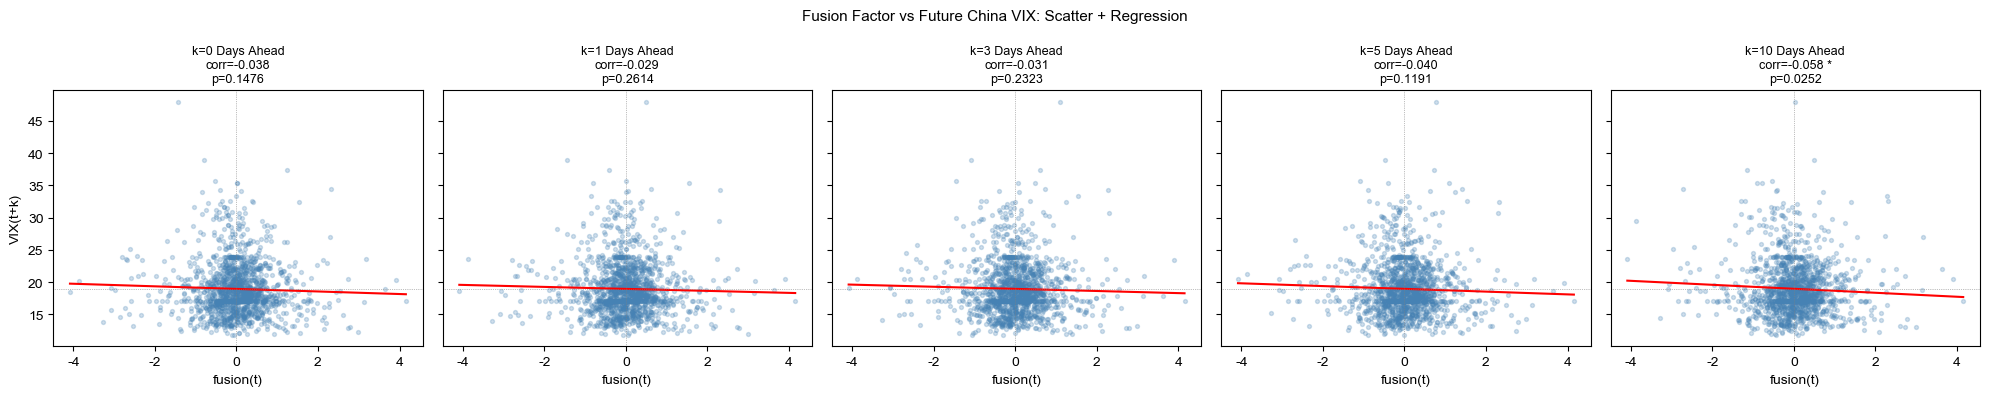

已保存: /Users/zhanghongyi/Desktop/Github/VINS Project/b_program/p3_adjusted_program/factor_test/outputs/03_fusion_vs_vix/01_scatter_regression.png


In [4]:
n_h   = len(HORIZONS)
fig, axes = plt.subplots(1, n_h, figsize=(4*n_h, 4), sharey=True)
if n_h == 1: axes = [axes]

for ax, k in zip(axes, HORIZONS):
    vix_future = df[VIX_COL].shift(-k)
    sub = pd.DataFrame({'x': df['fusion'], 'y': vix_future}).dropna()
    r, p = pearsonr(sub['x'], sub['y'])
    slope, intercept, *_ = stats.linregress(sub['x'], sub['y'])
    ax.scatter(sub['x'], sub['y'], alpha=0.25, s=8, color='steelblue')
    x_line = np.linspace(sub['x'].min(), sub['x'].max(), 100)
    ax.plot(x_line, slope*x_line+intercept, color='red', linewidth=1.5)
    sig = ' *' if p<0.05 else ''
    ax.set_title(f'k={k} Days Ahead\ncorr={r:.3f}{sig}\np={p:.4f}', fontsize=9)
    ax.set_xlabel('fusion(t)')
    if k == HORIZONS[0]: ax.set_ylabel('VIX(t+k)')
    ax.axhline(sub['y'].mean(), color='grey', linewidth=0.5, linestyle=':')
    ax.axvline(0, color='grey', linewidth=0.5, linestyle=':')

plt.suptitle('Fusion Factor vs Future China VIX: Scatter + Regression', fontsize=11)
plt.tight_layout()
out_path = os.path.join(out_dir,'01_scatter_regression.png')
plt.savefig(out_path, dpi=150); plt.show()
print('已保存:', out_path)

## 3. 大信号事件研究：fusion > 阈值后的 VIX 路径

In [5]:
high_signal_dates = df[df['fusion'] > HIGH_SIGNAL_THRESHOLD][DATE_COL].tolist()
print(f'fusion > {HIGH_SIGNAL_THRESHOLD} 的交易日数: {len(high_signal_dates)}')

dates_list   = df[DATE_COL].tolist()
vix_series   = df[VIX_COL].values
window       = EVENT_WINDOW

event_vix_paths, event_labels = [], []
for d in high_signal_dates:
    if d not in dates_list: continue
    idx = dates_list.index(d)
    if idx < window or idx+window >= len(dates_list): continue
    vix_w = vix_series[idx-window: idx+window+1].astype(float)
    if np.any(np.isnan(vix_w)): continue
    event_vix_paths.append(vix_w - vix_w[window])
    event_labels.append(d)

normal_mask  = (df['fusion'] >= -0.5) & (df['fusion'] <= 0.5)
normal_dates = df[normal_mask][DATE_COL].tolist()
normal_vix_paths = []
for d in normal_dates:
    if d not in dates_list: continue
    idx = dates_list.index(d)
    if idx < window or idx+window >= len(dates_list): continue
    vix_w = vix_series[idx-window: idx+window+1].astype(float)
    if np.any(np.isnan(vix_w)): continue
    normal_vix_paths.append(vix_w - vix_w[window])

print(f'有效大信号事件: {len(event_vix_paths)}, 对照组（Normal Days）: {len(normal_vix_paths)}')

fusion > 2.0 的交易日数: 24
有效大信号事件: 24, 对照组（Normal Days）: 944


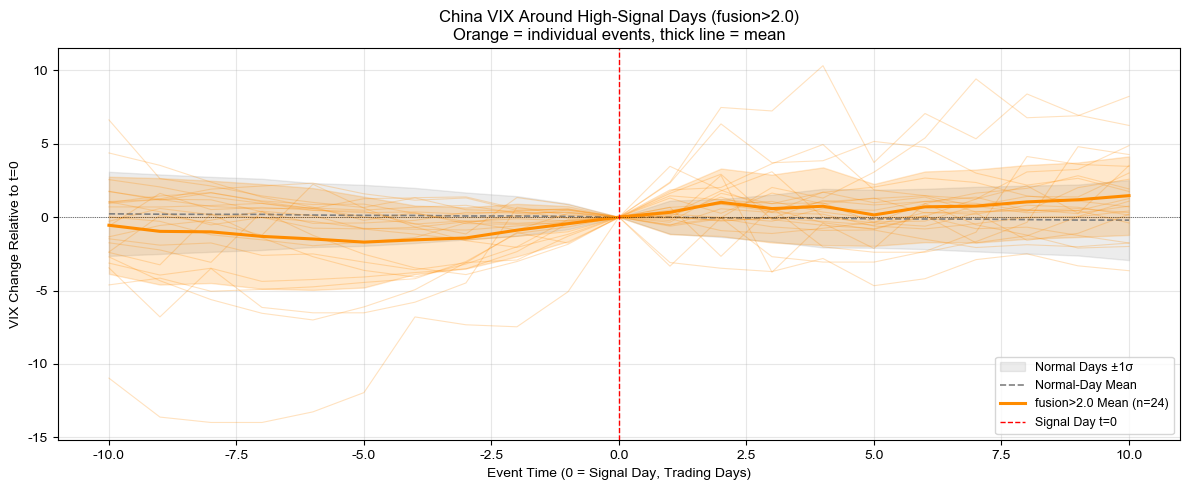

已保存: /Users/zhanghongyi/Desktop/Github/VINS Project/b_program/p3_adjusted_program/factor_test/outputs/03_fusion_vs_vix/02_event_study_vix_path.png


In [6]:
t_axis = np.arange(-window, window+1)
fig, ax = plt.subplots(figsize=(12, 5))

if normal_vix_paths:
    n_arr  = np.array(normal_vix_paths)
    n_mean = np.nanmean(n_arr, axis=0)
    n_std  = np.nanstd(n_arr,  axis=0)
    ax.fill_between(t_axis, n_mean-n_std, n_mean+n_std, alpha=0.15, color='grey', label='Normal Days ±1σ')
    ax.plot(t_axis, n_mean, color='grey', linewidth=1.2, linestyle='--', label='Normal-Day Mean')

if event_vix_paths:
    e_arr  = np.array(event_vix_paths)
    for path in e_arr:
        ax.plot(t_axis, path, color='darkorange', alpha=0.25, linewidth=0.8)
    e_mean = np.nanmean(e_arr, axis=0)
    e_std  = np.nanstd(e_arr,  axis=0)
    ax.fill_between(t_axis, e_mean-e_std, e_mean+e_std, alpha=0.20, color='darkorange')
    ax.plot(t_axis, e_mean, color='darkorange', linewidth=2.2,
            label=f'fusion>{HIGH_SIGNAL_THRESHOLD} Mean (n={len(event_vix_paths)})')

ax.axvline(0, color='red', linestyle='--', linewidth=1.0, label='Signal Day t=0')
ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.set_xlabel('Event Time (0 = Signal Day, Trading Days)')
ax.set_ylabel('VIX Change Relative to t=0')
ax.set_title(f'China VIX Around High-Signal Days (fusion>{HIGH_SIGNAL_THRESHOLD})\nOrange = individual events, thick line = mean')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out_path = os.path.join(out_dir,'02_event_study_vix_path.png')
plt.savefig(out_path, dpi=150); plt.show()
print('已保存:', out_path)

In [7]:
if event_vix_paths:
    e_arr = np.array(event_vix_paths)
    rows  = []
    for fd in [1,3,5,10]:
        vals = e_arr[:, window+fd]
        t_stat, p_val = stats.ttest_1samp(vals[~np.isnan(vals)], 0)
        rows.append({'T+N': f'T+{fd}',
                     '均值变化': round(np.nanmean(vals),4),
                     '中位数变化': round(np.nanmedian(vals),4),
                     '下降比例': f'{(vals<0).mean():.1%}',
                     't统计量': round(t_stat,3),
                     'p值': round(p_val,4)})
    df_event_stat = pd.DataFrame(rows)
    print(f'Signal Days后 VIX 变化统计（n={len(event_vix_paths)}）:')
    print(df_event_stat.to_string(index=False))

Signal Days后 VIX 变化统计（n=24）:
 T+N   均值变化   中位数变化  下降比例  t统计量     p值
 T+1 0.3280  0.1175 37.5% 1.055 0.3024
 T+3 0.5811  0.3575 37.5% 1.206 0.2401
 T+5 0.1503 -0.2066 54.2% 0.342 0.7354
T+10 1.4628  0.9181 20.8% 2.624 0.0152


## 4. Fusion Factor与 VIX 时序对比图

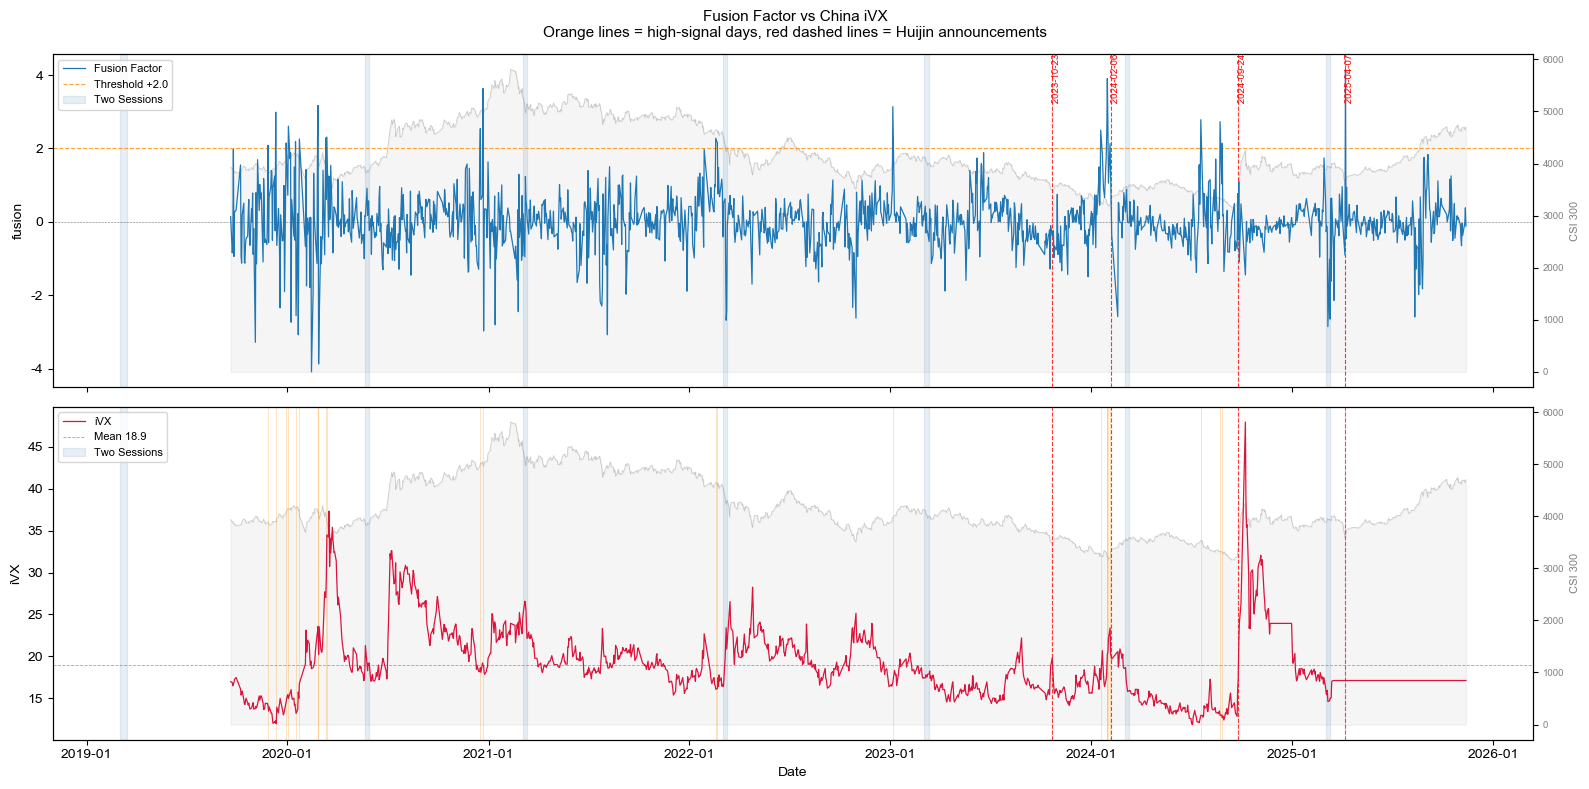

已保存: /Users/zhanghongyi/Desktop/Github/VINS Project/b_program/p3_adjusted_program/factor_test/outputs/03_fusion_vs_vix/03_timeseries_comparison.png


In [8]:
_f300 = next((f for f in os.listdir(DATA_DIR)
              if all(k in f for k in getattr(config,'FILE_KEYWORDS_CSI300',('CSI 300','行情')))
              and any(f.endswith(ext) for ext in config.EXCEL_EXTENSIONS)
              and not f.startswith(config.SKIP_FILE_PREFIX)), None)
df_price = None
if _f300:
    _tmp = pd.read_excel(os.path.join(DATA_DIR, _f300))
    _tmp.columns = _tmp.columns.str.strip()
    _tmp[DATE_COL] = pd.to_datetime(_tmp[DATE_COL], errors='coerce').dt.date
    if '收盘价' in _tmp.columns:
        _s = _tmp['收盘价']
        if _s.dtype == object or pd.api.types.is_string_dtype(_s):
            _s = _s.astype(str).str.replace(',','')
        _tmp['收盘价'] = pd.to_numeric(_s, errors='coerce')
        df_price = _tmp[[DATE_COL,'收盘价']].dropna().sort_values(DATE_COL).reset_index(drop=True)

_lh_raw = getattr(config,'LIANGHUI_PERIODS',[])
lianghui_periods = [(datetime.strptime(s,'%Y-%m-%d').date(),
                     datetime.strptime(e,'%Y-%m-%d').date()) for s,e in _lh_raw]

fig, (ax_top, ax_bot) = plt.subplots(2,1, figsize=(16,8), sharex=True,
                                      gridspec_kw={'height_ratios':[1,1]})

def _add_overlays(ax, add_orange_lines=False):
    _done = False
    for (s_d,e_d) in lianghui_periods:
        ax.axvspan(s_d, e_d, color='steelblue', alpha=0.13, zorder=0,
                   label='Two Sessions' if not _done else ''); _done=True
    for d_str in MARK_DATES:
        d = datetime.strptime(d_str,'%Y-%m-%d').date()
        ax.axvline(x=d, color='red', linestyle='--', linewidth=0.8, alpha=0.8)
    if add_orange_lines:
        for d in high_signal_dates:
            ax.axvline(x=d, color='darkorange', linewidth=0.5, alpha=0.35)

def _add_price_bg(ax):
    if df_price is None: return
    d_min, d_max = df[DATE_COL].min(), df[DATE_COL].max()
    bg = df_price[(df_price[DATE_COL]>=d_min)&(df_price[DATE_COL]<=d_max)]
    if len(bg)==0: return
    ax2 = ax.twinx()
    ax2.fill_between(bg[DATE_COL], bg['收盘价'], alpha=0.08, color='grey')
    ax2.plot(bg[DATE_COL], bg['收盘价'], color='grey', linewidth=0.5, alpha=0.4)
    ax2.set_ylabel('CSI 300', color='grey', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='grey', labelsize=7)
    ax2.set_zorder(1)

# 上图：Fusion Factor
ax_top.plot(df[DATE_COL], df['fusion'], color='#1f77b4', linewidth=0.9, zorder=3, label='Fusion Factor')
ax_top.axhline(HIGH_SIGNAL_THRESHOLD, color='darkorange', linewidth=0.8, linestyle='--',
               alpha=0.8, label=f'Threshold +{HIGH_SIGNAL_THRESHOLD}')
ax_top.axhline(0, color='black', linewidth=0.4, linestyle=':')
_add_overlays(ax_top)
_add_price_bg(ax_top)
y_top = ax_top.get_ylim()[1]
for d_str in MARK_DATES:
    d = datetime.strptime(d_str,'%Y-%m-%d').date()
    ax_top.text(d, y_top, f' {d}', color='red', fontsize=7, rotation=90, ha='left', va='top')
ax_top.set_ylabel('fusion')
ax_top.legend(loc='upper left', fontsize=8)
ax_top.set_zorder(2); ax_top.patch.set_visible(False)

# 下图：VIX
ax_bot.plot(df[DATE_COL], df[VIX_COL], color='crimson', linewidth=0.9, zorder=3, label='iVX')
ax_bot.axhline(df[VIX_COL].mean(), color='grey', linewidth=0.6, linestyle='--',
               alpha=0.7, label=f'Mean {df[VIX_COL].mean():.1f}')
_add_overlays(ax_bot, add_orange_lines=True)
_add_price_bg(ax_bot)
ax_bot.set_ylabel('iVX'); ax_bot.set_xlabel('Date')
ax_bot.legend(loc='upper left', fontsize=8)
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
ax_bot.set_zorder(2); ax_bot.patch.set_visible(False)

plt.suptitle('Fusion Factor vs China iVX\nOrange lines = high-signal days, red dashed lines = Huijin announcements', fontsize=11)
plt.tight_layout()
out_path = os.path.join(out_dir,'03_timeseries_comparison.png')
plt.savefig(out_path, dpi=150); plt.show()
print('已保存:', out_path)

In [9]:
out_xlsx = os.path.join(out_dir,'03_regression_and_event_stats.xlsx')
with pd.ExcelWriter(out_xlsx) as writer:
    df_results.to_excel(writer, sheet_name='多窗口回归', index=False)
    if event_vix_paths:
        df_event_stat.to_excel(writer, sheet_name='大信号事件统计', index=False)
print('结果已输出:', out_xlsx)

结果已输出: /Users/zhanghongyi/Desktop/Github/VINS Project/b_program/p3_adjusted_program/factor_test/outputs/03_fusion_vs_vix/03_regression_and_event_stats.xlsx


## 5. 国家队出手与CSI 300：连跌模式分析

分析Signal Days（fusion > 2）**之前**CSI 300的连跌情况，以及出手前后的累计涨跌路径。

In [10]:
# ── 读取CSI 300日度涨跌幅 ─────────────────────────────────────────────
_f300 = next((f for f in os.listdir(DATA_DIR)
              if all(k in f for k in getattr(config,'FILE_KEYWORDS_CSI300',('CSI 300','行情')))
              and any(f.endswith(ext) for ext in config.EXCEL_EXTENSIONS)
              and not f.startswith(config.SKIP_FILE_PREFIX)), None)
if _f300 is None:
    raise FileNotFoundError('未找到CSI 300行情文件')

df300 = pd.read_excel(os.path.join(DATA_DIR, _f300))
df300.columns = df300.columns.str.strip()
df300[DATE_COL] = pd.to_datetime(df300[DATE_COL], errors='coerce').dt.date

# 涨跌幅列
pct_col = next((c for c in df300.columns if '涨跌幅' in str(c)), None)
if pct_col is None:
    raise KeyError('未找到涨跌幅列，请检查CSI 300行情文件列名: ' + str(df300.columns.tolist()))
pct_col_str = str(pct_col)
df300[pct_col] = pd.to_numeric(df300[pct_col], errors='coerce')
df300 = df300[[DATE_COL, pct_col]].dropna().sort_values(DATE_COL).rename(
    columns={pct_col: 'pct_csi300'}).reset_index(drop=True)

# ── 与Fusion Factor合并 ────────────────────────────────────────────────────
df_all = df_fusion.merge(df300, on=DATE_COL, how='inner').sort_values(DATE_COL).reset_index(drop=True)
print(f'CSI 300行数: {len(df300)}，合并后: {len(df_all)}')
print(f'CSI 300涨跌幅列: "{pct_col_str}"')
print(df300['pct_csi300'].describe().round(3))

CSI 300行数: 2431，合并后: 1489
CSI 300涨跌幅列: "涨跌幅(%)"
count    2431.000
mean        0.016
std         1.207
min        -7.880
25%        -0.570
50%         0.020
75%         0.620
max         8.480
Name: pct_csi300, dtype: float64


In [11]:
# ── Signal Days前的连跌统计 ──────────────────────────────────────────────
# 对每个Signal Days，统计触发前 1/3/5/10 日内：下跌天数、累计涨跌幅
high_sig_dates_300 = df_all[df_all['fusion'] > HIGH_SIGNAL_THRESHOLD][DATE_COL].tolist()
dates_300 = df_all[DATE_COL].tolist()
pct_arr   = df_all['pct_csi300'].values

rows_pre = []
for d in high_sig_dates_300:
    if d not in dates_300: continue
    idx = dates_300.index(d)
    for lookback in [1, 3, 5, 10]:
        if idx < lookback: continue
        window_pct = pct_arr[idx-lookback:idx].astype(float)
        rows_pre.append({
            '信号日': d,
            '回望天数': lookback,
            '下跌天数': int((window_pct < 0).sum()),
            '下跌比例': round((window_pct < 0).mean(), 3),
            '累计涨跌幅': round(window_pct.sum(), 3)
        })

df_pre = pd.DataFrame(rows_pre)

# 汇总：按回望天数分组求均值
summary_pre = df_pre.groupby('回望天数')[['下跌比例','累计涨跌幅']].mean().round(4).reset_index()
summary_pre.columns = ['回望天数', '平均下跌比例', '平均累计涨跌幅(%)']

# 对照组：Normal Days的同样统计
normal_mask_300 = (df_all['fusion'] >= -0.5) & (df_all['fusion'] <= 0.5)
normal_dates_300 = df_all[normal_mask_300][DATE_COL].tolist()
rows_norm = []
for d in normal_dates_300:
    if d not in dates_300: continue
    idx = dates_300.index(d)
    for lookback in [1, 3, 5, 10]:
        if idx < lookback: continue
        window_pct = pct_arr[idx-lookback:idx].astype(float)
        rows_norm.append({'回望天数': lookback,
                          '下跌比例': (window_pct < 0).mean(),
                          '累计涨跌幅': window_pct.sum()})

df_norm = pd.DataFrame(rows_norm)
summary_norm = df_norm.groupby('回望天数')[['下跌比例','累计涨跌幅']].mean().round(4).reset_index()
summary_norm.columns = ['回望天数', '平均下跌比例_对照组', '平均累计涨跌幅_对照组(%)']

summary = summary_pre.merge(summary_norm, on='回望天数')
print(f'\nSignal Days（fusion>{HIGH_SIGNAL_THRESHOLD}，n={len(high_sig_dates_300)}）触发前CSI 300统计 vs Normal Days对照:')
print(summary.to_string(index=False))


Signal Days（fusion>2.0，n=24）触发前CSI 300统计 vs Normal Days对照:
 回望天数  平均下跌比例  平均累计涨跌幅(%)  平均下跌比例_对照组  平均累计涨跌幅_对照组(%)
    1  0.5000     -0.2171      0.4859          0.0614
    3  0.4722     -0.2288      0.4876          0.1151
    5  0.5000     -0.2350      0.4892          0.1305
   10  0.5125      0.1358      0.4875          0.2583


In [12]:
# ── 事件研究：Signal Days前后CSI 300累计涨跌幅路径 ──────────────────────
window_300 = EVENT_WINDOW
event_cum_paths, normal_cum_paths = [], []

for d in high_sig_dates_300:
    if d not in dates_300: continue
    idx = dates_300.index(d)
    if idx < window_300 or idx+window_300 >= len(dates_300): continue
    pct_w = pct_arr[idx-window_300: idx+window_300+1].astype(float)
    if np.any(np.isnan(pct_w)): continue
    # 累计涨跌幅，从 t=-10 开始累积，t=0 时归零（相对于出手当天）
    cum = np.cumsum(pct_w)
    cum = cum - cum[window_300]   # 归一化：t=0 时为 0
    event_cum_paths.append(cum)

for d in normal_dates_300:
    if d not in dates_300: continue
    idx = dates_300.index(d)
    if idx < window_300 or idx+window_300 >= len(dates_300): continue
    pct_w = pct_arr[idx-window_300: idx+window_300+1].astype(float)
    if np.any(np.isnan(pct_w)): continue
    cum = np.cumsum(pct_w)
    cum = cum - cum[window_300]
    normal_cum_paths.append(cum)

print(f'有效大信号事件: {len(event_cum_paths)}，对照组: {len(normal_cum_paths)}')

有效大信号事件: 24，对照组: 944


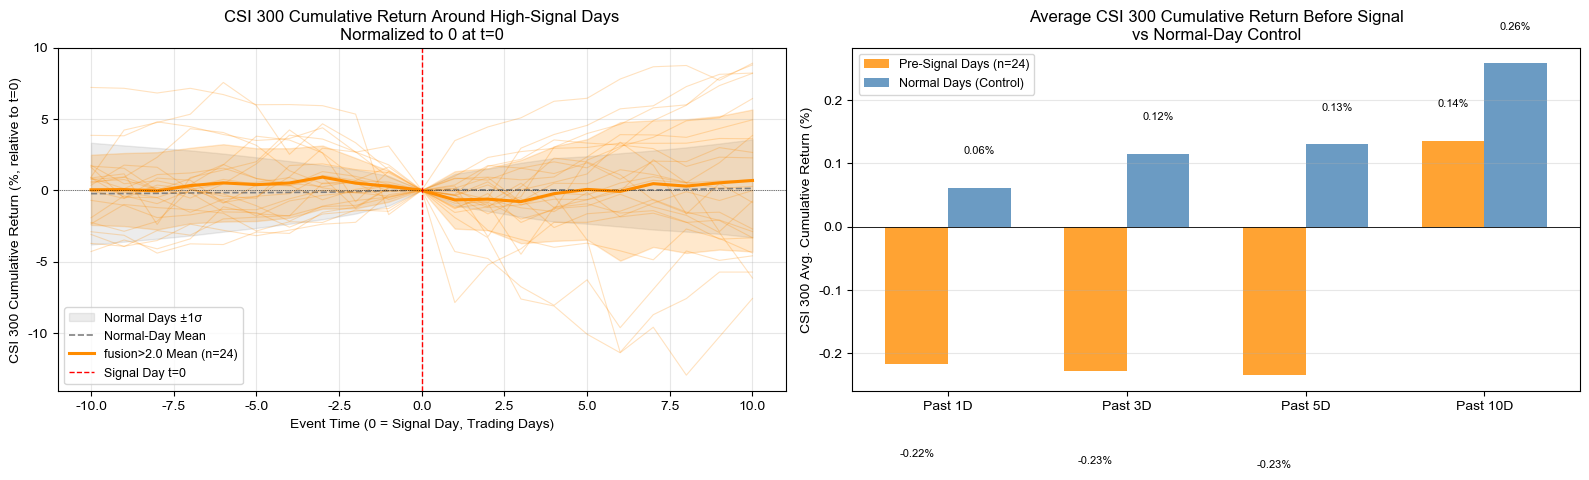

已保存: /Users/zhanghongyi/Desktop/Github/VINS Project/b_program/p3_adjusted_program/factor_test/outputs/03_fusion_vs_vix/04_csi300_pattern_around_signal.png


In [13]:
# ── 绘图 ─────────────────────────────────────────────────────────────
t_axis = np.arange(-window_300, window_300+1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---- 左图：事件研究路径 ----
ax = axes[0]
if normal_cum_paths:
    n_arr  = np.array(normal_cum_paths)
    n_mean = np.nanmean(n_arr, axis=0)
    n_std  = np.nanstd(n_arr,  axis=0)
    ax.fill_between(t_axis, n_mean-n_std, n_mean+n_std, alpha=0.15, color='grey', label='Normal Days ±1σ')
    ax.plot(t_axis, n_mean, color='grey', linewidth=1.2, linestyle='--', label='Normal-Day Mean')

if event_cum_paths:
    e_arr  = np.array(event_cum_paths)
    for path in e_arr:
        ax.plot(t_axis, path, color='darkorange', alpha=0.25, linewidth=0.8)
    e_mean = np.nanmean(e_arr, axis=0)
    e_std  = np.nanstd(e_arr,  axis=0)
    ax.fill_between(t_axis, e_mean-e_std, e_mean+e_std, alpha=0.20, color='darkorange')
    ax.plot(t_axis, e_mean, color='darkorange', linewidth=2.2,
            label=f'fusion>{HIGH_SIGNAL_THRESHOLD} Mean (n={len(event_cum_paths)})')

ax.axvline(0, color='red', linestyle='--', linewidth=1.0, label='Signal Day t=0')
ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax.set_xlabel('Event Time (0 = Signal Day, Trading Days)')
ax.set_ylabel('CSI 300 Cumulative Return (%, relative to t=0)')
ax.set_title(f'CSI 300 Cumulative Return Around High-Signal Days\nNormalized to 0 at t=0')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ---- 右图：触发前 N 日平均累计跌幅对比柱状图 ----
ax2 = axes[1]
x   = np.arange(len(summary))
w   = 0.35
bars1 = ax2.bar(x - w/2, summary['平均累计涨跌幅(%)'],  w,
                color='darkorange', alpha=0.8, label=f'Pre-Signal Days (n={len(high_sig_dates_300)})')
bars2 = ax2.bar(x + w/2, summary['平均累计涨跌幅_对照组(%)'], w,
                color='steelblue', alpha=0.8, label='Normal Days (Control)')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Past {n}D' for n in summary['回望天数']])
ax2.set_ylabel('CSI 300 Avg. Cumulative Return (%)')
ax2.set_title('Average CSI 300 Cumulative Return Before Signal\nvs Normal-Day Control')
ax2.axhline(0, color='black', linewidth=0.6)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    h = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2, h + (0.05 if h>=0 else -0.15),
             f'{h:.2f}%', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2, h + (0.05 if h>=0 else -0.15),
             f'{h:.2f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
out_path = os.path.join(out_dir,'04_csi300_pattern_around_signal.png')
plt.savefig(out_path, dpi=150)
plt.show()
print('已保存:', out_path)

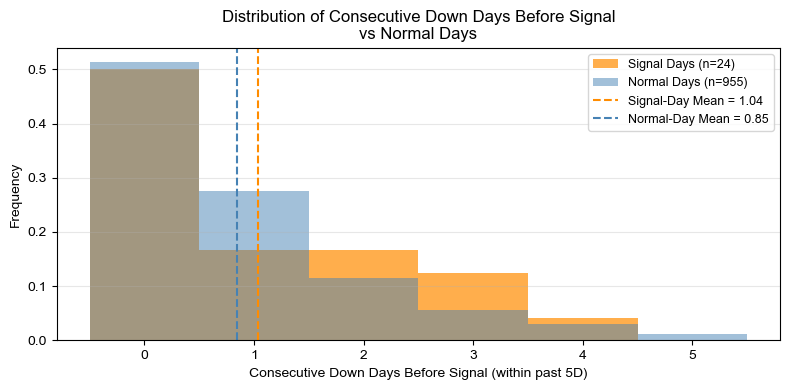

Signal-Day mean consecutive declines: 1.04 days | Normal days: 0.85 days
已保存: /Users/zhanghongyi/Desktop/Github/VINS Project/b_program/p3_adjusted_program/factor_test/outputs/03_fusion_vs_vix/05_consecutive_down_days.png


In [14]:
# ── 连跌天数分布直方图 ────────────────────────────────────────────────
# 信号日前 5 天内的连续下跌天数
LOOKBACK = 5
consec_down_signal, consec_down_normal = [], []

def count_trailing_down(pct_window):
    """从最后一日往前数，连续下跌的天数（从 t=-1 往前）。"""
    n = 0
    for v in reversed(pct_window):
        if v < 0: n += 1
        else: break
    return n

for d in high_sig_dates_300:
    if d not in dates_300: continue
    idx = dates_300.index(d)
    if idx < LOOKBACK: continue
    w = pct_arr[idx-LOOKBACK:idx].astype(float)
    consec_down_signal.append(count_trailing_down(w))

for d in normal_dates_300:
    if d not in dates_300: continue
    idx = dates_300.index(d)
    if idx < LOOKBACK: continue
    w = pct_arr[idx-LOOKBACK:idx].astype(float)
    consec_down_normal.append(count_trailing_down(w))

bins = np.arange(0, LOOKBACK+2) - 0.5
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(consec_down_signal, bins=bins, density=True, alpha=0.7, color='darkorange',
        label=f'Signal Days (n={len(consec_down_signal)})')
ax.hist(consec_down_normal, bins=bins, density=True, alpha=0.5, color='steelblue',
        label=f'Normal Days (n={len(consec_down_normal)})')
ax.set_xticks(range(LOOKBACK+1))
ax.set_xlabel(f'Consecutive Down Days Before Signal (within past {LOOKBACK}D)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Consecutive Down Days Before Signal\nvs Normal Days')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# 均值标注
m_sig = np.mean(consec_down_signal)
m_nor = np.mean(consec_down_normal)
ax.axvline(m_sig, color='darkorange', linewidth=1.5, linestyle='--', label=f'Signal-Day Mean = {m_sig:.2f}')
ax.axvline(m_nor, color='steelblue',  linewidth=1.5, linestyle='--', label=f'Normal-Day Mean = {m_nor:.2f}')
ax.legend(fontsize=9)

plt.tight_layout()
out_path = os.path.join(out_dir,'05_consecutive_down_days.png')
plt.savefig(out_path, dpi=150)
plt.show()
print(f'Signal-Day mean consecutive declines: {m_sig:.2f} days | Normal days: {m_nor:.2f} days')
print('已保存:', out_path)

## 6. 扩展分析：多时间尺度跌幅、最大回撤与下跌持续时长

寻找可汇报的强信号：国家队出手前CSI 300究竟跌了多少、跌了多久？

In [15]:
# ── 计算每个日期的多维特征 ────────────────────────────────────────────
# df_all 已包含 DATE_COL / fusion / pct_csi300
# 重新读取CSI 300收盘价（需要绝对价格计算回撤）
_f300 = next((f for f in os.listdir(DATA_DIR)
              if all(k in f for k in getattr(config,'FILE_KEYWORDS_CSI300',('CSI 300','行情')))
              and any(f.endswith(ext) for ext in config.EXCEL_EXTENSIONS)
              and not f.startswith(config.SKIP_FILE_PREFIX)), None)
df300_full = pd.read_excel(os.path.join(DATA_DIR, _f300))
df300_full.columns = df300_full.columns.str.strip()
df300_full[DATE_COL] = pd.to_datetime(df300_full[DATE_COL], errors='coerce').dt.date
pct_col2 = next((c for c in df300_full.columns if '涨跌幅' in str(c)), None)
close_col = next((c for c in df300_full.columns if '收盘' in str(c)), None)
df300_full[pct_col2]   = pd.to_numeric(df300_full[pct_col2],   errors='coerce')
df300_full[close_col]  = pd.to_numeric(
    df300_full[close_col].astype(str).str.replace(',',''), errors='coerce')
df300_full = df300_full[[DATE_COL, pct_col2, close_col]].dropna().sort_values(DATE_COL).reset_index(drop=True)
df300_full = df300_full.rename(columns={pct_col2:'pct', close_col:'close'})
print('CSI 300完整数据行数:', len(df300_full))
print('列:', df300_full.columns.tolist())

CSI 300完整数据行数: 2431
列: ['交易日期', 'pct', 'close']


In [16]:
# ── 对每个日期计算多维指标 ────────────────────────────────────────────
dates_full  = df300_full[DATE_COL].tolist()
close_arr   = df300_full['close'].values
pct_arr2    = df300_full['pct'].values

LOOKBACKS = [1, 3, 5, 10, 20, 60]   # 多时间尺度回望窗口（交易日）
DRAWDOWN_WINDOW = 252                # 用近1年高点计算最大回撤

def get_features(idx):
    feats = {}
    # 1. 多时间尺度累计涨跌幅
    for lb in LOOKBACKS:
        if idx >= lb:
            feats[f'cum_ret_{lb}d'] = float(np.sum(pct_arr2[idx-lb:idx]))
        else:
            feats[f'cum_ret_{lb}d'] = np.nan
    # 2. 从近1年高点的回撤
    start = max(0, idx - DRAWDOWN_WINDOW)
    window_close = close_arr[start:idx+1]
    peak = np.max(window_close)
    feats['drawdown_from_peak'] = (close_arr[idx] - peak) / peak * 100
    # 3. 连续下跌天数（从今天往前数连续跌了几天）
    n_consec = 0
    for j in range(idx-1, max(-1, idx-LOOKBACKS[-1]-1), -1):
        if pct_arr2[j] < 0: n_consec += 1
        else: break
    feats['consec_down_days'] = n_consec
    # 4. 过去 20 日下跌天数占比
    if idx >= 20:
        feats['down_days_ratio_20d'] = float((pct_arr2[idx-20:idx] < 0).mean())
    else:
        feats['down_days_ratio_20d'] = np.nan
    return feats

# 只对Signal Days和对照组计算
high_sig_set  = set(high_sig_dates_300)
normal_set_300 = set(normal_dates_300)
all_target_dates = list(high_sig_set | normal_set_300)

feature_rows = []
for d in all_target_dates:
    if d not in dates_full: continue
    idx = dates_full.index(d)
    if idx < DRAWDOWN_WINDOW: continue
    row = get_features(idx)
    row['date'] = d
    row['group'] = '大信号' if d in high_sig_set else '正常'
    feature_rows.append(row)

df_feat = pd.DataFrame(feature_rows)
print('特征表行数:', len(df_feat))
print('Signal Days:', (df_feat['group']=='大信号').sum(), '  Normal Days:', (df_feat['group']=='正常').sum())

特征表行数: 980
Signal Days: 24   Normal Days: 956


In [17]:
# ── 汇总对比表：均值与中位数 ──────────────────────────────────────────
feat_cols = [f'cum_ret_{lb}d' for lb in LOOKBACKS] + \
            ['drawdown_from_peak', 'consec_down_days', 'down_days_ratio_20d']

rows_summary = []
for fc in feat_cols:
    sig_vals  = df_feat[df_feat['group']=='大信号'][fc].dropna()
    norm_vals = df_feat[df_feat['group']=='正常'][fc].dropna()
    if len(sig_vals) < 5 or len(norm_vals) < 5: continue
    t_stat, p_val = stats.ttest_ind(sig_vals, norm_vals, equal_var=False)
    rows_summary.append({
        '指标': fc,
        'Signal Days均值': round(sig_vals.mean(), 3),
        'Signal Days中位数': round(sig_vals.median(), 3),
        'Normal-Day Mean': round(norm_vals.mean(), 3),
        'Normal Days中位数': round(norm_vals.median(), 3),
        '差值(大信号-正常)': round(sig_vals.mean()-norm_vals.mean(), 3),
        'p值': round(p_val, 4),
        '显著': '✓' if p_val < 0.05 else ''
    })

df_summary = pd.DataFrame(rows_summary)
print('多维特征对比（Signal Days vs Normal Days）:')
print(df_summary.to_string(index=False))

多维特征对比（Signal Days vs Normal Days）:
                 指标  Signal Days均值  Signal Days中位数  Normal-Day Mean  Normal Days中位数  差值(大信号-正常)     p值 显著
         cum_ret_1d         -0.217           0.020            0.062           0.020      -0.279 0.4532   
         cum_ret_3d         -0.229           0.080            0.114           0.130      -0.343 0.4885   
         cum_ret_5d         -0.235           0.185            0.130           0.150      -0.365 0.5365   
        cum_ret_10d          0.136           0.240            0.253           0.115      -0.117 0.8441   
        cum_ret_20d         -0.459          -0.220            0.511           0.430      -0.970 0.2062   
        cum_ret_60d         -0.594           0.860            1.465           0.210      -2.059 0.1698   
 drawdown_from_peak        -11.263          -9.690          -11.528         -11.445       0.265 0.8858   
   consec_down_days          1.042           0.500            0.849           0.000       0.192 0.4691   
down_days_

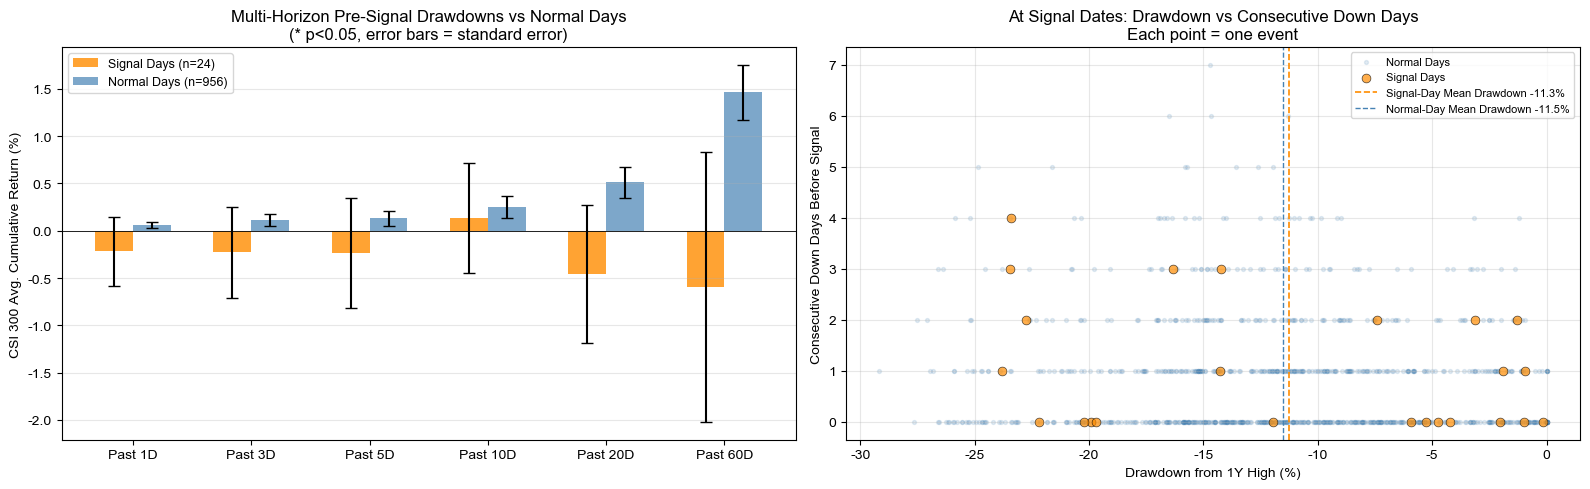

已保存: /Users/zhanghongyi/Desktop/Github/VINS Project/b_program/p3_adjusted_program/factor_test/outputs/03_fusion_vs_vix/06_multiscale_drawdown_analysis.png


In [18]:
# ── 图1：多时间尺度累计跌幅对比（箱线图）────────────────────────────
import matplotlib.patches as mpatches

cum_cols = [f'cum_ret_{lb}d' for lb in LOOKBACKS]
sig_data  = [df_feat[df_feat['group']=='大信号'][c].dropna().values for c in cum_cols]
norm_data = [df_feat[df_feat['group']=='正常'][c].dropna().values  for c in cum_cols]

x = np.arange(len(LOOKBACKS))
w = 0.32
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 左图：均值+误差棒
ax = axes[0]
means_sig  = [np.mean(v) for v in sig_data]
sems_sig   = [stats.sem(v) for v in sig_data]
means_norm = [np.mean(v) for v in norm_data]
sems_norm  = [stats.sem(v) for v in norm_data]

ax.bar(x-w/2, means_sig,  w, yerr=sems_sig,  color='darkorange', alpha=0.8, capsize=4,
       label=f'Signal Days (n={len(sig_data[0])})')
ax.bar(x+w/2, means_norm, w, yerr=sems_norm, color='steelblue',  alpha=0.7, capsize=4,
       label=f'Normal Days (n={len(norm_data[0])})')
for i, (ms, mn, ps) in enumerate(zip(means_sig, means_norm,
                                      [stats.ttest_ind(sig_data[i],norm_data[i],equal_var=False).pvalue
                                       for i in range(len(LOOKBACKS))])):
    if ps < 0.05:
        ymax = max(abs(ms), abs(mn)) + max(sems_sig[i], sems_norm[i])
        ax.text(i, ymax+0.05, '*', ha='center', fontsize=14, color='red')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels([f'Past {lb}D' for lb in LOOKBACKS])
ax.set_ylabel('CSI 300 Avg. Cumulative Return (%)')
ax.set_title('Multi-Horizon Pre-Signal Drawdowns vs Normal Days\n(* p<0.05, error bars = standard error)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# 右图：回撤 vs 连续下跌天数 散点（Signal Days vs Normal Days）
ax2 = axes[1]
sig_sub  = df_feat[df_feat['group']=='大信号'].dropna(subset=['drawdown_from_peak','consec_down_days'])
norm_sub = df_feat[df_feat['group']=='正常'].dropna(subset=['drawdown_from_peak','consec_down_days'])
ax2.scatter(norm_sub['drawdown_from_peak'], norm_sub['consec_down_days'],
            alpha=0.15, s=8, color='steelblue', label='Normal Days')
ax2.scatter(sig_sub['drawdown_from_peak'],  sig_sub['consec_down_days'],
            alpha=0.7,  s=40, color='darkorange', zorder=5, label='Signal Days', edgecolors='k', linewidths=0.5)
ax2.axvline(sig_sub['drawdown_from_peak'].mean(), color='darkorange', linestyle='--', linewidth=1.2,
            label=f'Signal-Day Mean Drawdown {sig_sub["drawdown_from_peak"].mean():.1f}%')
ax2.axvline(norm_sub['drawdown_from_peak'].mean(), color='steelblue', linestyle='--', linewidth=1.0,
            label=f'Normal-Day Mean Drawdown {norm_sub["drawdown_from_peak"].mean():.1f}%')
ax2.set_xlabel('Drawdown from 1Y High (%)')
ax2.set_ylabel('Consecutive Down Days Before Signal')
ax2.set_title('At Signal Dates: Drawdown vs Consecutive Down Days\nEach point = one event')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
out_path = os.path.join(out_dir,'06_multiscale_drawdown_analysis.png')
plt.savefig(out_path, dpi=150)
plt.show()
print('已保存:', out_path)

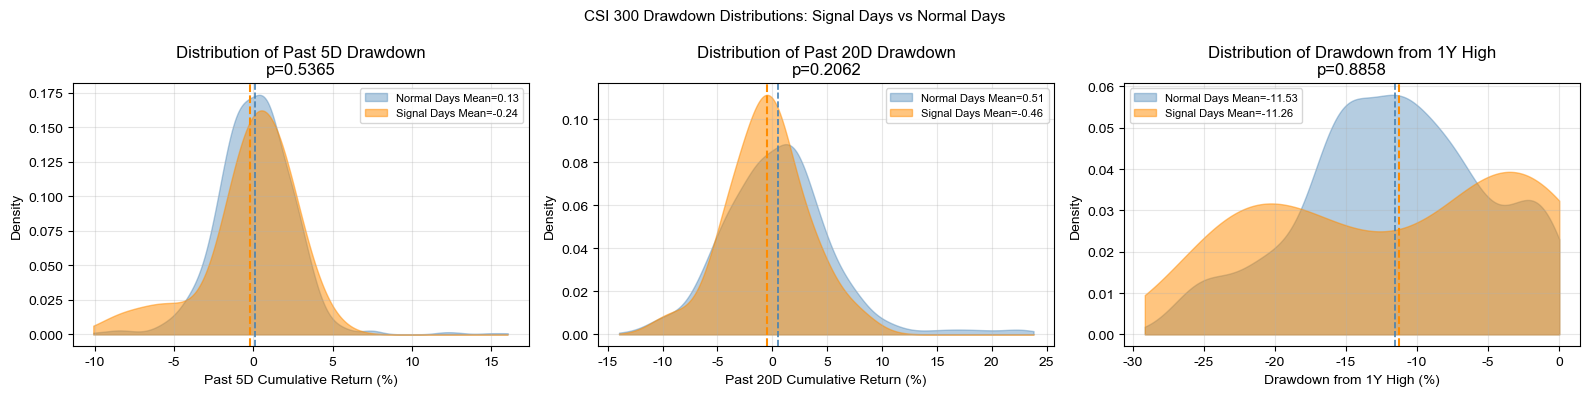

已保存: /Users/zhanghongyi/Desktop/Github/VINS Project/b_program/p3_adjusted_program/factor_test/outputs/03_fusion_vs_vix/07_drawdown_kde_distribution.png


In [19]:
# ── 图2：回撤分布Density图（核Density） ────────────────────────────────────
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

def plot_kde_comparison(ax, feat, xlabel, title):
    sig_v  = df_feat[df_feat['group']=='大信号'][feat].dropna().values
    norm_v = df_feat[df_feat['group']=='正常'][feat].dropna().values
    xmin = min(sig_v.min(), norm_v.min())
    xmax = max(sig_v.max(), norm_v.max())
    xs   = np.linspace(xmin, xmax, 300)
    ax.fill_between(xs, gaussian_kde(norm_v)(xs), alpha=0.4, color='steelblue', label=f'Normal Days Mean={norm_v.mean():.2f}')
    ax.fill_between(xs, gaussian_kde(sig_v)(xs),  alpha=0.5, color='darkorange',label=f'Signal Days Mean={sig_v.mean():.2f}')
    ax.axvline(sig_v.mean(),  color='darkorange', linewidth=1.5, linestyle='--')
    ax.axvline(norm_v.mean(), color='steelblue',  linewidth=1.2, linestyle='--')
    _, p = stats.ttest_ind(sig_v, norm_v, equal_var=False)
    ax.set_title(f'{title}\np={p:.4f}{" ✓" if p<0.05 else ""}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plot_kde_comparison(axes[0], 'cum_ret_5d',  'Past 5D Cumulative Return (%)', 'Distribution of Past 5D Drawdown')
plot_kde_comparison(axes[1], 'cum_ret_20d', 'Past 20D Cumulative Return (%)', 'Distribution of Past 20D Drawdown')
plot_kde_comparison(axes[2], 'drawdown_from_peak', 'Drawdown from 1Y High (%)', 'Distribution of Drawdown from 1Y High')

plt.suptitle('CSI 300 Drawdown Distributions: Signal Days vs Normal Days', fontsize=11)
plt.tight_layout()
out_path = os.path.join(out_dir,'07_drawdown_kde_distribution.png')
plt.savefig(out_path, dpi=150)
plt.show()
print('已保存:', out_path)

/var/folders/nw/qn0916dd3g12_8kqhgfzzgp40000gn/T/ipykernel_18646/1547209649.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_dd = df_all_feat.groupby('dd_bin')['is_signal'].agg(['mean','count']).reset_index()
/var/folders/nw/qn0916dd3g12_8kqhgfzzgp40000gn/T/ipykernel_18646/1547209649.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_cum = df_all_feat.groupby('cum20_bin')['is_signal'].agg(['mean','count']).reset_index()


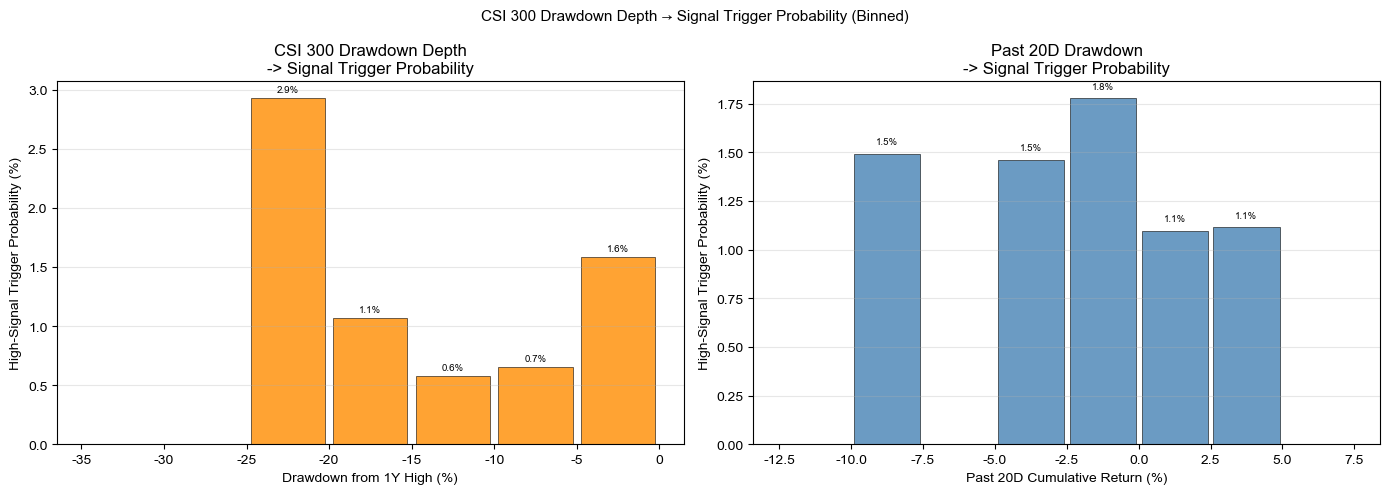

已保存: /Users/zhanghongyi/Desktop/Github/VINS Project/b_program/p3_adjusted_program/factor_test/outputs/03_fusion_vs_vix/08_intervention_probability_by_drawdown.png


In [20]:
# ── 图3：回撤阈值 → 出手概率曲线（关键！）────────────────────────────
# 对所有交易日，按「距高点回撤深度」分桶，计算每桶内是Signal Days的比例

# 先对所有日期都算回撤
all_feature_rows = []
for d in dates_full:
    idx = dates_full.index(d)
    if idx < DRAWDOWN_WINDOW: continue
    start = max(0, idx - DRAWDOWN_WINDOW)
    peak  = np.max(close_arr[start:idx+1])
    dd    = (close_arr[idx] - peak) / peak * 100
    cum5  = float(np.sum(pct_arr2[idx-5:idx])) if idx >= 5 else np.nan
    cum20 = float(np.sum(pct_arr2[idx-20:idx])) if idx >= 20 else np.nan
    is_signal = 1 if d in high_sig_set else 0
    all_feature_rows.append({'date': d, 'drawdown': dd,
                              'cum5': cum5, 'cum20': cum20,
                              'is_signal': is_signal})

df_all_feat = pd.DataFrame(all_feature_rows).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：按回撤分桶，统计出手概率
ax = axes[0]
bins_dd = np.arange(-50, 5, 5)
df_all_feat['dd_bin'] = pd.cut(df_all_feat['drawdown'], bins=bins_dd)
prob_dd = df_all_feat.groupby('dd_bin')['is_signal'].agg(['mean','count']).reset_index()
prob_dd = prob_dd[prob_dd['count'] >= 10]
bin_mids = [interval.mid for interval in prob_dd['dd_bin']]
ax.bar(bin_mids, prob_dd['mean']*100, width=4.5, color='darkorange', alpha=0.8, edgecolor='k', linewidth=0.5)
ax.set_xlabel('Drawdown from 1Y High (%)')
ax.set_ylabel('High-Signal Trigger Probability (%)')
ax.set_title('CSI 300 Drawdown Depth\n-> Signal Trigger Probability')
ax.grid(True, alpha=0.3, axis='y')
for mid, prob, cnt in zip(bin_mids, prob_dd['mean'], prob_dd['count']):
    if prob*100 > 0.3:
        ax.text(mid, prob*100+0.05, f'{prob*100:.1f}%', ha='center', fontsize=7)

# 右图：按前20日累计跌幅分桶，统计出手概率
ax2 = axes[1]
bins_cum = np.arange(-25, 10, 2.5)
df_all_feat['cum20_bin'] = pd.cut(df_all_feat['cum20'], bins=bins_cum)
prob_cum = df_all_feat.groupby('cum20_bin')['is_signal'].agg(['mean','count']).reset_index()
prob_cum = prob_cum[prob_cum['count'] >= 10]
bin_mids2 = [interval.mid for interval in prob_cum['cum20_bin']]
ax2.bar(bin_mids2, prob_cum['mean']*100, width=2.3, color='steelblue', alpha=0.8, edgecolor='k', linewidth=0.5)
ax2.set_xlabel('Past 20D Cumulative Return (%)')
ax2.set_ylabel('High-Signal Trigger Probability (%)')
ax2.set_title('Past 20D Drawdown\n-> Signal Trigger Probability')
ax2.grid(True, alpha=0.3, axis='y')
for mid, prob, cnt in zip(bin_mids2, prob_cum['mean'], prob_cum['count']):
    if prob*100 > 0.3:
        ax2.text(mid, prob*100+0.05, f'{prob*100:.1f}%', ha='center', fontsize=7)

plt.suptitle('CSI 300 Drawdown Depth → Signal Trigger Probability (Binned)', fontsize=11)
plt.tight_layout()
out_path = os.path.join(out_dir,'08_intervention_probability_by_drawdown.png')
plt.savefig(out_path, dpi=150)
plt.show()
print('已保存:', out_path)

In [21]:
# ── 汇总打印强信号发现 ────────────────────────────────────────────────
print('='*60)
print('关键发现汇总')
print('='*60)
for _, row in df_summary.iterrows():
    if row['显著'] == '✓':
        print(f"✓ {row['指标']:25s}  大信号均值={row['Signal Days均值']:+.3f}  "
              f"Normal-Day Mean={row['Normal-Day Mean']:+.3f}  "
              f"差值={row['差值(大信号-正常)']:+.3f}  p={row['p值']:.4f}")
sig_dd_mean  = df_feat[df_feat['group']=='大信号']['drawdown_from_peak'].mean()
norm_dd_mean = df_feat[df_feat['group']=='正常']['drawdown_from_peak'].mean()
print(f"\n距1年高点回撤: Signal Days均值={sig_dd_mean:.2f}%  Normal-Day Mean={norm_dd_mean:.2f}%")

关键发现汇总

距1年高点回撤: Signal Days均值=-11.26%  Normal-Day Mean=-11.53%
